In [1]:
from pyarrow import Tensor

from opensynth.models.faraday.losses import mmd_loss
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

import logging
logging.basicConfig(level=logging.INFO)

In [3]:
LCL_PROCESSED_DATA_PATH = Path("../data/processed/historical/")
LCL_RAW_DATA_PATH = Path("../data/raw/historical/")

GOIENER_PROCESSED_DATA_PATH = Path("../data/processed/goiener/historical/")
GOIENER_RAW_DATA_PATH = Path("../data/raw/goiener/historical/")


TRAINED_FARADAY_PATH = Path("./faraday/")
TRAINED_ENERGYDIFF_PATH = Path("./energydiff/")

# 💿 Loading Data

In [4]:
from opensynth.data_modules.lcl_data_module import LCLDataModule
from opensynth.data_modules.goiener_data_module import GoiEnerDataModule
import pytorch_lightning as pl

import matplotlib.pyplot as plt

## LCL

In [5]:
data_path = LCL_PROCESSED_DATA_PATH / "train/lcl_data.csv"
stats_path = LCL_PROCESSED_DATA_PATH / "train/mean_std.csv"
outlier_path = LCL_PROCESSED_DATA_PATH / "train/outliers.csv"

# Original training data with no outliers
dm_lcl = LCLDataModule(data_path=data_path, stats_path=stats_path, batch_size=200, n_samples=20000)
dm_lcl.setup()

gmm_lcl_data_module = LCLDataModule(data_path=data_path, stats_path=stats_path, batch_size=25000, n_samples=100000)
gmm_lcl_data_module.setup()

In [6]:
# Holdout data
holdout_lcl_path = LCL_PROCESSED_DATA_PATH / "holdout/lcl_data.csv"
dm_lcl_holdout = LCLDataModule(data_path=holdout_lcl_path, stats_path=stats_path, batch_size=200, n_samples=20000)
dm_lcl_holdout.setup()

# Outlier
dm_lcl_with_outliers = LCLDataModule(data_path=data_path, stats_path=stats_path, batch_size=5000, n_samples=20000, outlier_path=outlier_path)
dm_lcl_with_outliers.setup()

## GoiEner

In [7]:
data_path = GOIENER_PROCESSED_DATA_PATH / "train/goiener_data.csv"
stats_path = GOIENER_PROCESSED_DATA_PATH / "train/mean_std.csv"
outlier_path = GOIENER_PROCESSED_DATA_PATH / "train/outliers.csv"

# Original training data with no outliers
dm_goiener = GoiEnerDataModule(data_path=data_path, stats_path=stats_path, batch_size=200, n_samples=20000)
dm_goiener.setup()

gmm_goiener_data_module = GoiEnerDataModule(data_path=data_path, stats_path=stats_path, batch_size=25000, n_samples=100000)
gmm_goiener_data_module.setup()

# Outlier
dm_goiener_with_outliers = GoiEnerDataModule(data_path=data_path, stats_path=stats_path, batch_size=5000, n_samples=20000, outlier_path=outlier_path)
dm_goiener_with_outliers.setup()

In [8]:
# Holdout data
holdout_goiener_path = GOIENER_PROCESSED_DATA_PATH / "holdout/goiener_data.csv"
dm_goiener_holdout = GoiEnerDataModule(data_path=holdout_goiener_path, stats_path=stats_path, batch_size=200, n_samples=20000)
dm_goiener_holdout.setup()

# 🤖 Load Pretrained models

In [9]:
from opensynth.models.faraday.model import FaradayModel
from opensynth.models.energydiff.diffusion import PLDiffusion1D
import numpy as np
import torch

/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## LCL Faraday

In [10]:
faraday_lcl_models = {}
for n_components in [10, 50, 150]:
    faraday_lcl_models[n_components] = torch.load(TRAINED_FARADAY_PATH / f"faraday_model_{n_components}.pt", weights_only=False)

## LCL EnergyDiff

In [11]:
model_path = TRAINED_ENERGYDIFF_PATH / "lightning_logs" / "version_3" / "checkpoints/" / "epoch=99-step=1900.ckpt"
kwh_path = TRAINED_ENERGYDIFF_PATH / "lightning_logs" / "version_3" / "samples" / "dpm_kwh_calib.pt"
df_lcl_model = PLDiffusion1D.load_from_checkpoint(model_path)
df_lcl_kwh = torch.load(kwh_path)

## GoiEner Faraday

In [12]:
faraday_goiener_models = {}
for n_components in [10, 50, 150]:
    faraday_goiener_models[n_components] = torch.load(TRAINED_FARADAY_PATH / f"goiener_faraday_model_{n_components}.pt", weights_only=False)

## GoiEner EnergyDiff

In [13]:
model_path = TRAINED_ENERGYDIFF_PATH / "lightning_logs" / "version_2" / "checkpoints/" / "epoch=99-step=1900.ckpt"
kwh_path = TRAINED_ENERGYDIFF_PATH / "lightning_logs" / "version_2" / "samples" / "dpm_kwh_calib.pt"
df_goiener_model = PLDiffusion1D.load_from_checkpoint(model_path)
df_goiener_kwh = torch.load(kwh_path)
df_goiener_kwh = torch.clip(df_goiener_kwh, min=0) # Clip min 0 to get read of negative values

# 📈 Comparing Results

### 0. Generating Samples

In [14]:
def generate_faraday_synthetic_samples(model, n_samples, dm):
    gmm_samples = model.sample_gmm(n_samples)
    gmm_samples_reconstructed = dm.reconstruct_kwh(gmm_samples['kwh'])
    gmm_samples_reconstructed = torch.clip(gmm_samples_reconstructed, min=0)
    return gmm_samples_reconstructed[:25000]

### LCL Faraday

In [15]:
gmm_lcl_150 = generate_faraday_synthetic_samples(faraday_lcl_models[150], 30000, dm_lcl)
gmm_lcl_50 = generate_faraday_synthetic_samples(faraday_lcl_models[50], 30000, dm_lcl)
gmm_lcl_10 = generate_faraday_synthetic_samples(faraday_lcl_models[10], 30000, dm_lcl)

In [16]:
real_lcl_kwh = dm_lcl.reconstruct_kwh(next(iter(gmm_lcl_data_module.train_dataloader()))['kwh'])
real_lcl_kwh = torch.clip(real_lcl_kwh, min=0) # Clip min 0 to get read of negative values

### GoiEner Faraday

In [17]:
gmm_goiener_150 = generate_faraday_synthetic_samples(faraday_goiener_models[150], 30000, dm_goiener)
gmm_goiener_50 = generate_faraday_synthetic_samples(faraday_goiener_models[50], 30000, dm_goiener)
gmm_goiener_10 = generate_faraday_synthetic_samples(faraday_goiener_models[10], 30000, dm_goiener)

In [18]:
real_goiener_kwh = dm_goiener.reconstruct_kwh(next(iter(gmm_goiener_data_module.train_dataloader()))['kwh'])
real_goiener_kwh = torch.clip(real_goiener_kwh, min=0) # Clip min 0 to get read of negative values

### LCL/GoiEner EnergyDiff already generated

In [19]:
# df_lcl_kwh, df_lcl_model, df_goiener_kwh, df_goiener_model

### 1. Comparing mean, 95th quantile, median profiles

In [20]:
def plot_stats(real_kwh, gmm_reconstruct):

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 3), sharey=True, gridspec_kw={'wspace': 0.05})

    ax1.plot(real_kwh.mean(dim=0).detach().numpy(), label="real kwh")
    ax1.plot(gmm_reconstruct.mean(dim=0).detach().numpy(), label="gmm kwh")
    ax1.set_title("Mean kWh per half hour")
    ax1.set_xlabel("Settlement Periods")
    ax1.legend()

    ax2.plot(real_kwh.quantile(0.95, dim=0).detach().numpy(), label="real kwh")
    ax2.plot(gmm_reconstruct.quantile(0.95, dim=0).detach().numpy(), label="gmm kwh")
    ax2.set_title("95th Quantile kWh per half hour")
    ax2.set_xlabel("Settlement Periods")
    ax2.legend()

    ax3.plot(real_kwh.quantile(0.5, dim=0).detach().numpy(), label="real kwh")
    ax3.set_title("Median kWh per half hour")
    ax3.set_xlabel("Settlement Periods")
    ax3.plot(gmm_reconstruct.quantile(0.5, dim=0).detach().numpy(), label="gmm kwh")
    ax3.legend()

    fig.text(0.1, 0.5, 'kWh', va='center', rotation='vertical')

In [21]:
os.makedirs('figures', exist_ok=True)

In [22]:
def plot_stats_2(real_lcl_kwh, real_goiener_kwh, gmm_lcl_reconstruct, gmm_goiener_reconstruct, name):

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 3), sharey=True, gridspec_kw={'wspace': 0.05})

    ax1.plot(real_lcl_kwh.mean(dim=0).detach().numpy(), label="real kWh (LCL)")
    ax1.plot(gmm_lcl_reconstruct.mean(dim=0).detach().numpy(), label="gmm kWh (LCL)")
    ax1.plot(real_goiener_kwh.mean(dim=0).detach().numpy(), label="real kWh (GoiEner)")
    ax1.plot(gmm_goiener_reconstruct.mean(dim=0).detach().numpy(), label="gmm kWh (GoiEner)")

    ax1.set_title("Mean kWh per half hour")
    ax1.set_xlabel("Settlement Periods")
    # ax1.legend()


    ax2.plot(real_lcl_kwh.quantile(0.95, dim=0).detach().numpy(), label="real kwh (LCL)")
    ax2.plot(gmm_lcl_reconstruct.quantile(0.95, dim=0).detach().numpy(), label="gmm kwh (LCL)")
    ax2.plot(real_goiener_kwh.quantile(0.95, dim=0).detach().numpy(), label="real kwh (GoiEner)")
    ax2.plot(gmm_goiener_reconstruct.quantile(0.95, dim=0).detach().numpy(), label="gmm kwh (GoiEner)")

    ax2.set_title("95th Quantile kWh per half hour")
    ax2.set_xlabel("Settlement Periods")
    # ax2.legend()


    ax3.plot(real_lcl_kwh.quantile(0.5, dim=0).detach().numpy(), label="real kwh (LCL)")
    ax3.plot(gmm_lcl_reconstruct.quantile(0.5, dim=0).detach().numpy(), label="gmm kwh (LCL)")
    ax3.plot(real_goiener_kwh.quantile(0.5, dim=0).detach().numpy(), label="real kwh (GoiEner)")
    ax3.plot(gmm_goiener_reconstruct.quantile(0.5, dim=0).detach().numpy(), label="gmm kwh (GoiEner)")

    ax3.set_title("Median kWh per half hour")
    ax3.set_xlabel("Settlement Periods")
    # ax3.legend()

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.5, 0.5))

    fig.text(0.1, 0.5, 'kWh', va='center', rotation='vertical')

    plt.savefig(f"figures/{name}.png", dpi=300, bbox_inches='tight')

In [19]:
import seaborn as sns
def plot_stats_3(real_lcl_kwh, real_goiener_kwh,
                 gmm_lcl_150_reconstruct,
                 gmm_lcl_50_reconstruct,
                 gmm_lcl_10_reconstruct,
                 gmm_lcl_ediff_reconstruct,
                 gmm_goiener_150_reconstruct,
                 gmm_goiener_50_reconstruct,
                 gmm_goiener_10_reconstruct,
                 gmm_goiener_ediff_reconstruct,
                 name):
    fig, axes = plt.subplots(4, 3, figsize=(16, 10), sharex=True, sharey=True, gridspec_kw={'wspace': 0.05})

    axes_flat = axes.flatten()
    ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12 = axes_flat

    ax1.plot(real_lcl_kwh.mean(dim=0).detach().numpy())
    ax1.plot(gmm_lcl_150_reconstruct.mean(dim=0).detach().numpy())
    ax1.plot(real_goiener_kwh.mean(dim=0).detach().numpy())
    ax1.plot(gmm_goiener_150_reconstruct.mean(dim=0).detach().numpy())

    ax2.plot(real_lcl_kwh.quantile(0.95, dim=0).detach().numpy())
    ax2.plot(gmm_lcl_150_reconstruct.quantile(0.95, dim=0).detach().numpy())
    ax2.plot(real_goiener_kwh.quantile(0.95, dim=0).detach().numpy())
    ax2.plot(gmm_goiener_150_reconstruct.quantile(0.95, dim=0).detach().numpy())

    ax3.plot(real_lcl_kwh.quantile(0.5, dim=0).detach().numpy())
    ax3.plot(gmm_lcl_150_reconstruct.quantile(0.5, dim=0).detach().numpy())
    ax3.plot(real_goiener_kwh.quantile(0.5, dim=0).detach().numpy())
    ax3.plot(gmm_goiener_150_reconstruct.quantile(0.5, dim=0).detach().numpy())

    ax4.plot(real_lcl_kwh.mean(dim=0).detach().numpy())
    ax4.plot(gmm_lcl_50_reconstruct.mean(dim=0).detach().numpy())
    ax4.plot(real_goiener_kwh.mean(dim=0).detach().numpy())
    ax4.plot(gmm_goiener_50_reconstruct.mean(dim=0).detach().numpy())

    ax5.plot(real_lcl_kwh.quantile(0.95, dim=0).detach().numpy())
    ax5.plot(gmm_lcl_50_reconstruct.quantile(0.95, dim=0).detach().numpy())
    ax5.plot(real_goiener_kwh.quantile(0.95, dim=0).detach().numpy())
    ax5.plot(gmm_goiener_50_reconstruct.quantile(0.95, dim=0).detach().numpy())

    ax6.plot(real_lcl_kwh.quantile(0.5, dim=0).detach().numpy())
    ax6.plot(gmm_lcl_50_reconstruct.quantile(0.5, dim=0).detach().numpy())
    ax6.plot(real_goiener_kwh.quantile(0.5, dim=0).detach().numpy())
    ax6.plot(gmm_goiener_50_reconstruct.quantile(0.5, dim=0).detach().numpy())

    ax7.plot(real_lcl_kwh.mean(dim=0).detach().numpy())
    ax7.plot(gmm_lcl_10_reconstruct.mean(dim=0).detach().numpy())
    ax7.plot(real_goiener_kwh.mean(dim=0).detach().numpy())
    ax7.plot(gmm_goiener_10_reconstruct.mean(dim=0).detach().numpy())

    ax8.plot(real_lcl_kwh.quantile(0.95, dim=0).detach().numpy())
    ax8.plot(gmm_lcl_10_reconstruct.quantile(0.95, dim=0).detach().numpy())
    ax8.plot(real_goiener_kwh.quantile(0.95, dim=0).detach().numpy())
    ax8.plot(gmm_goiener_10_reconstruct.quantile(0.95, dim=0).detach().numpy())

    ax9.plot(real_lcl_kwh.quantile(0.5, dim=0).detach().numpy())
    ax9.plot(gmm_lcl_10_reconstruct.quantile(0.5, dim=0).detach().numpy())
    ax9.plot(real_goiener_kwh.quantile(0.5, dim=0).detach().numpy())
    ax9.plot(gmm_goiener_10_reconstruct.quantile(0.5, dim=0).detach().numpy())

    ax10.plot(real_lcl_kwh.mean(dim=0).detach().numpy())
    ax10.plot(gmm_lcl_ediff_reconstruct.mean(dim=0).detach().numpy())
    ax10.plot(real_goiener_kwh.mean(dim=0).detach().numpy())
    ax10.plot(gmm_goiener_ediff_reconstruct.mean(dim=0).detach().numpy())
    ax10.set_xlabel("Settlement Periods", fontsize=20)

    ax11.plot(real_lcl_kwh.quantile(0.95, dim=0).detach().numpy())
    ax11.plot(gmm_lcl_ediff_reconstruct.quantile(0.95, dim=0).detach().numpy())
    ax11.plot(real_goiener_kwh.quantile(0.95, dim=0).detach().numpy())
    ax11.plot(gmm_goiener_ediff_reconstruct.quantile(0.95, dim=0).detach().numpy())
    ax11.set_xlabel("Settlement Periods", fontsize=20)

    ax12.plot(real_lcl_kwh.quantile(0.5, dim=0).detach().numpy(), label="real (LCL)")
    ax12.plot(gmm_lcl_ediff_reconstruct.quantile(0.5, dim=0).detach().numpy(), label="synthetic (LCL)")
    ax12.plot(real_goiener_kwh.quantile(0.5, dim=0).detach().numpy(), label="real (GoiEner)")
    ax12.plot(gmm_goiener_ediff_reconstruct.quantile(0.5, dim=0).detach().numpy(), label="synthetic (GoiEner)")
    ax12.set_xlabel("Settlement Periods", fontsize=20)

    cols = ["Mean kWh per half hour", "95th Quantile kWh per half hour", "Median kWh per half hour"]
    rows = ["Faraday 150\nkWh", "Faraday 50\nkWh", "Faraday 10\nkWh", "EnergyDiff\nkWh"]
    for ax, col in zip(axes[0], cols):
        ax.set_title(col, fontsize=16)
        # ax.set_facecolor("white")
        # ax.grid(which='major', axis='y', linestyle='--', color='#DDDDDD')

    for ax, row in zip(axes[:,0], rows):
        ax.set_ylabel(row, rotation='vertical', size='x-large')
        # ax.set_facecolor("white")
        # ax.grid(which='major', axis='y', linestyle='--', color='#DDDDDD')

    handles, labels = ax12.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0), ncol = 4, fontsize=16)
    # fig.tight_layout()
    # fig.text(0.1, 0.5, 'kWh', va='center', rotation='vertical')

    plt.savefig(f"figures/{name}.png", dpi=300, bbox_inches='tight')

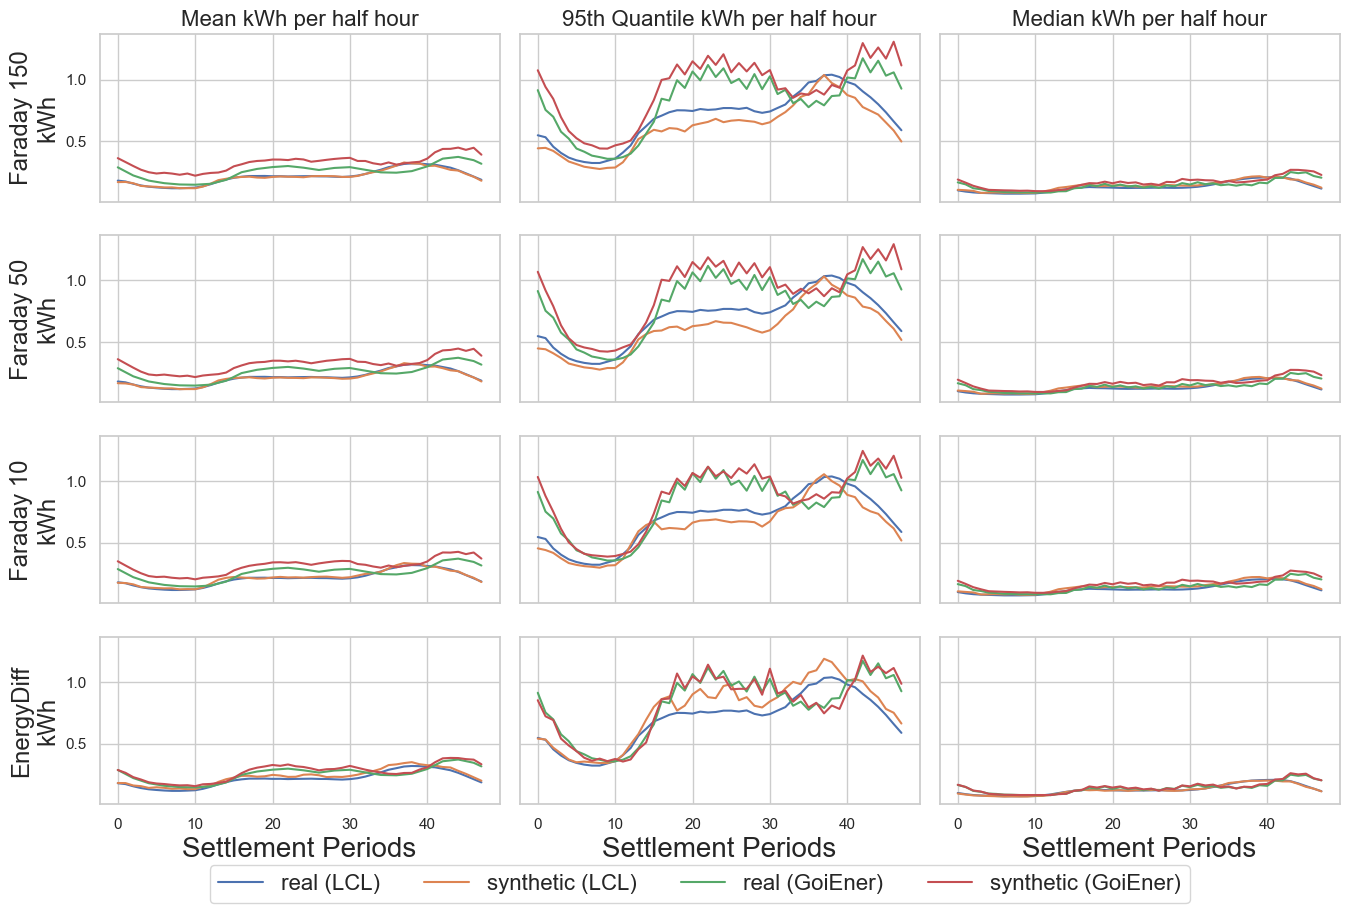

In [20]:
sns.set_theme(style="whitegrid")
plot_stats_3(real_lcl_kwh, real_goiener_kwh,
             gmm_lcl_150,
             gmm_lcl_50,
             gmm_lcl_10,
             df_lcl_kwh,
             gmm_goiener_150,
             gmm_goiener_50,
             gmm_goiener_10,
             df_goiener_kwh,
            "comp_quant_all")

In [114]:
# plot_stats_2(real_lcl_kwh, real_goiener_kwh, gmm_lcl_150, gmm_goiener_150, "comp_gmm_150")

In [115]:
# plot_stats_2(real_lcl_kwh, real_goiener_kwh, gmm_lcl_50, gmm_goiener_50, "comp_gmm_50")

In [116]:
# plot_stats_2(real_lcl_kwh, real_goiener_kwh, gmm_lcl_10, gmm_goiener_10, "comp_gmm_10")

In [117]:
# plot_stats_2(real_lcl_kwh, real_goiener_kwh, df_lcl_kwh, df_goiener_kwh, "comp_diff")

### 2. Deviation sum

In [67]:
def deviation_sum(real_kwh, gmm_reconstruct):
    """
    Calculate the deviation sum between real kWh and GMM reconstructed kWh.

    Args:
        real_kwh (torch.Tensor): Real kWh tensor.
        gmm_reconstruct (torch.Tensor): GMM reconstructed kWh tensor.

    Returns:
        torch.Tensor: Deviation sum.
    """
    return torch.abs(real_kwh-gmm_reconstruct).sum().detach().numpy()

In [174]:
print("Deviation sums:")
print("\n\nMean:\n")
print("LCL 150:", deviation_sum(real_lcl_kwh.mean(dim=0), gmm_lcl_150.mean(dim=0)))
print("LCL 50:", deviation_sum(real_lcl_kwh.mean(dim=0), gmm_lcl_50.mean(dim=0)))
print("LCL 10:", deviation_sum(real_lcl_kwh.mean(dim=0), gmm_lcl_10.mean(dim=0)))
print("LCL Diff:", deviation_sum(real_lcl_kwh.mean(dim=0), df_lcl_kwh.mean(dim=0)))

print("GoiEner 150:", deviation_sum(real_goiener_kwh.mean(dim=0), gmm_goiener_150.mean(dim=0)))
print("GoiEner 50:", deviation_sum(real_goiener_kwh.mean(dim=0), gmm_goiener_50.mean(dim=0)))
print("GoiEner 10:", deviation_sum(real_goiener_kwh.mean(dim=0), gmm_goiener_10.mean(dim=0)))
print("GoiEner Diff:", deviation_sum(real_goiener_kwh.mean(dim=0), df_goiener_kwh.mean(dim=0)))

print("\n\n95th Quantile:\n")
print("LCL 150:", deviation_sum(real_lcl_kwh.quantile(.95, dim=0), gmm_lcl_150.quantile(.95, dim=0)))
print("LCL 50:", deviation_sum(real_lcl_kwh.quantile(.95, dim=0), gmm_lcl_50.quantile(.95, dim=0)))
print("LCL 10:", deviation_sum(real_lcl_kwh.quantile(.95, dim=0), gmm_lcl_10.quantile(.95, dim=0)))
print("LCL Diff:", deviation_sum(real_lcl_kwh.quantile(.95, dim=0), df_lcl_kwh.quantile(.95, dim=0)))

print("GoiEner 150:", deviation_sum(real_goiener_kwh.quantile(.95, dim=0), gmm_goiener_150.quantile(.95, dim=0)))
print("GoiEner 50:", deviation_sum(real_goiener_kwh.quantile(.95, dim=0), gmm_goiener_50.quantile(.95, dim=0)))
print("GoiEner 10:", deviation_sum(real_goiener_kwh.quantile(.95, dim=0), gmm_goiener_10.quantile(.95, dim=0)))
print("GoiEner Diff:", deviation_sum(real_goiener_kwh.quantile(.95, dim=0), df_goiener_kwh.quantile(.95, dim=0)))

print("\n\nMedian:\n")
print("LCL 150:", deviation_sum(real_lcl_kwh.quantile(.5, dim=0), gmm_lcl_150.quantile(.5, dim=0)))
print("LCL 50:", deviation_sum(real_lcl_kwh.quantile(.5, dim=0), gmm_lcl_50.quantile(.5, dim=0)))
print("LCL 10:", deviation_sum(real_lcl_kwh.quantile(.5, dim=0), gmm_lcl_10.quantile(.5, dim=0)))
print("LCL Diff:", deviation_sum(real_lcl_kwh.quantile(.5, dim=0), df_lcl_kwh.quantile(.5, dim=0)))

print("GoiEner 150:", deviation_sum(real_goiener_kwh.quantile(.5, dim=0), gmm_goiener_150.quantile(.5, dim=0)))
print("GoiEner 50:", deviation_sum(real_goiener_kwh.quantile(.5, dim=0), gmm_goiener_50.quantile(.5, dim=0)))
print("GoiEner 10:", deviation_sum(real_goiener_kwh.quantile(.5, dim=0), gmm_goiener_10.quantile(.5, dim=0)))
print("GoiEner Diff:", deviation_sum(real_goiener_kwh.quantile(.5, dim=0), df_goiener_kwh.quantile(.5, dim=0)))


Deviation sums:


Mean:

LCL 150: 0.26923972
LCL 50: 0.2570973
LCL 10: 0.3666337
LCL Diff: 0.9840198
GoiEner 150: 3.8480768
GoiEner 50: 3.3994193
GoiEner 10: 3.2772708
GoiEner Diff: 0.8602406


95th Quantile:

LCL 150: 4.0826306
LCL 50: 3.8248684
LCL 10: 3.0636606
LCL Diff: 3.7793167
GoiEner 150: 6.573189
GoiEner 50: 4.7715607
GoiEner 10: 4.079393
GoiEner Diff: 1.5808535


Median:

LCL 150: 0.50459194
LCL 50: 0.51527435
LCL 10: 0.6901944
LCL Diff: 0.14200005
GoiEner 150: 1.1505005
GoiEner 50: 1.2249252
GoiEner 10: 1.2588868
GoiEner Diff: 0.22199988


### 3. PCA and TSNE Distribution Plots

In [69]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np


def train_pca_and_tsne(real_kwh, gmm_reconstruct):
    pca = PCA(n_components=2)
    tsne = TSNE(n_components=2)

    pca.fit(real_kwh.detach().numpy())
    pca_real = pca.transform(real_kwh.detach().numpy())
    pca_gmm = pca.transform(gmm_reconstruct.detach().numpy())

    tsne_input = np.concatenate([real_kwh.detach().numpy(), gmm_reconstruct.detach().numpy()])
    tsne_results = tsne.fit_transform(tsne_input)
    tsne_real = tsne_results[:len(real_kwh)]
    tsne_gmm = tsne_results[len(real_kwh):]

    return pca_real, pca_gmm, tsne_real, tsne_gmm


def plot_pca_tsne(pca_real, pca_gmm, tsne_real, tsne_gmm):
    fig, (ax_pca, ax_tsne) = plt.subplots(1, 2, figsize=(12, 4))

    ax_pca.scatter(pca_real[:, 0], pca_real[:, 1], label="real kwh", s=0.3, alpha=0.5)
    ax_pca.scatter(pca_gmm[:, 0], pca_gmm[:, 1], label="gmm kwh", s=0.3, alpha=0.5)
    ax_pca.set_title("PCA")
    ax_pca.set_xlabel("PCA 1")
    ax_pca.set_ylabel("PCA 2")
    ax_pca.legend()

    ax_tsne.scatter(tsne_real[:, 0], tsne_real[:, 1], label="real kwh", s=0.3, alpha=0.5)
    ax_tsne.scatter(tsne_gmm[:, 0], tsne_gmm[:, 1], label="gmm kwh", s=0.3, alpha=0.5)
    ax_tsne.set_title("TSNE")
    ax_tsne.set_xlabel("TSNE 1")
    ax_tsne.set_ylabel("TSNE 2")
    ax_tsne.legend()
    return fig


Text(0.5, 1.0, 'GMM with 150 clusters')

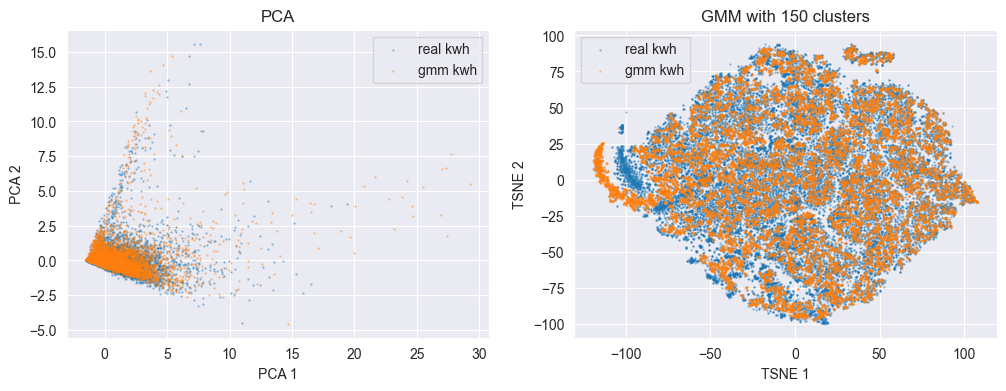

In [70]:
b1, b2, b3, b4 = train_pca_and_tsne(real_lcl_kwh, gmm_lcl_150)
_ = plot_pca_tsne(b1, b2, b3, b4)
plt.title("GMM with 150 clusters")

In [71]:
# c1, c2, c3, c4 = train_pca_and_tsne(real_kwh, gmm_50)
# _ = plot_pca_tsne(c1, c2, c3, c4)
# plt.title("GMM with 50 clusters")

In [72]:
# d1, d2, d3, d4 = train_pca_and_tsne(real_kwh, gmm_10)
# _ = plot_pca_tsne(d1, d2, d3, d4)
# plt.title("GMM with 10 clusters")

# 4 Reconstruction Attack


### 🏭 Create Reconstruction Attack Dataset

In [73]:
from opensynth.evaluation.privacy import reconstruction_attack

### LCL

In [74]:
# n_samples == batch_size
real_kwh = next(iter(dm_lcl_with_outliers.train_dataloader()))['kwh']
real_kwh = dm_lcl_with_outliers.reconstruct_kwh(real_kwh)
outlier_kwh = next(iter(dm_lcl_with_outliers.outlier_dataloader()))['kwh']
outlier_kwh = dm_lcl_with_outliers.reconstruct_kwh(outlier_kwh)

faraday150_lcl_attack_dataset = reconstruction_attack.create_attack_dataset(
    model=faraday_lcl_models[150], dm=dm_lcl_with_outliers, n_samples=20000
)

faraday50_lcl_attack_dataset = reconstruction_attack.create_attack_dataset(
    model=faraday_lcl_models[50], dm=dm_lcl_with_outliers, n_samples=20000
)

faraday10_lcl_attack_dataset = reconstruction_attack.create_attack_dataset(
    model=faraday_lcl_models[10], dm=dm_lcl_with_outliers, n_samples=20000
)

ediff_lcl_attack_dataset = reconstruction_attack.ReconstructionAttackDataset(
    synthetic_samples=df_lcl_kwh,
    real_samples=real_kwh,
    outlier_samples=outlier_kwh
)

### GoiEner

In [75]:
real_kwh = next(iter(dm_goiener_with_outliers.train_dataloader()))['kwh']
real_kwh = dm_goiener_with_outliers.reconstruct_kwh(real_kwh)
outlier_kwh = next(iter(dm_goiener_with_outliers.outlier_dataloader()))['kwh']
outlier_kwh = dm_goiener_with_outliers.reconstruct_kwh(outlier_kwh)

faraday150_goiener_attack_dataset = reconstruction_attack.create_attack_dataset(
    model=faraday_goiener_models[150], dm=dm_goiener_with_outliers, n_samples=20000
)

faraday50_goiener_attack_dataset = reconstruction_attack.create_attack_dataset(
    model=faraday_goiener_models[50], dm=dm_goiener_with_outliers, n_samples=20000
)

faraday10_goiener_attack_dataset = reconstruction_attack.create_attack_dataset(
    model=faraday_goiener_models[10], dm=dm_goiener_with_outliers, n_samples=20000
)

ediff_goiener_attack_dataset = reconstruction_attack.ReconstructionAttackDataset(
    synthetic_samples=df_goiener_kwh,
    real_samples=real_kwh,
    outlier_samples=outlier_kwh
)

### 🧮 Calculating pair-wise euclidean distances


### LCL

In [76]:
faraday150_lcl_distance_norm = reconstruction_attack.calculate_distance_norm(
    real = faraday150_lcl_attack_dataset.outlier_samples,
    fake = faraday150_lcl_attack_dataset.synthetic_samples,
    group_min=True
)

faraday50_lcl_distance_norm = reconstruction_attack.calculate_distance_norm(
    real = faraday50_lcl_attack_dataset.outlier_samples,
    fake = faraday50_lcl_attack_dataset.synthetic_samples,
    group_min=True
)

faraday10_lcl_distance_norm = reconstruction_attack.calculate_distance_norm(
    real = faraday10_lcl_attack_dataset.outlier_samples,
    fake = faraday10_lcl_attack_dataset.synthetic_samples,
    group_min=True
)

ediff_lcl_distance_norm = reconstruction_attack.calculate_distance_norm(
    real = ediff_lcl_attack_dataset.outlier_samples,
    fake = ediff_lcl_attack_dataset.synthetic_samples,
    group_min=True
)

### GoiEner

In [77]:
faraday150_goiener_distance_norm = reconstruction_attack.calculate_distance_norm(
    real = faraday150_goiener_attack_dataset.outlier_samples,
    fake = faraday150_goiener_attack_dataset.synthetic_samples,
    group_min=True
)

faraday50_goiener_distance_norm = reconstruction_attack.calculate_distance_norm(
    real = faraday50_goiener_attack_dataset.outlier_samples,
    fake = faraday50_goiener_attack_dataset.synthetic_samples,
    group_min=True
)

faraday10_goiener_distance_norm = reconstruction_attack.calculate_distance_norm(
    real = faraday10_goiener_attack_dataset.outlier_samples,
    fake = faraday10_goiener_attack_dataset.synthetic_samples,
    group_min=True
)

ediff_goiener_distance_norm = reconstruction_attack.calculate_distance_norm(
    real = ediff_goiener_attack_dataset.outlier_samples,
    fake = ediff_goiener_attack_dataset.synthetic_samples,
    group_min=True
)

### Plot Norms

In the defining good paper, it is recommended that threshold ratio be set to 0.3. This is analogous to saying that for a outlier profile with daily total consumption of 30kwh, a generated profile with total consumption within 30% (21±9kwh) is sufficient to render that outlier compromised.

Using this threshold, we can see that GMMs trained with 1500 clusters, about 16.5% of outliers would have rended about 53% of outliers successfully reconstructed, whilst GMM trained with only 1 cluster is very private. All synthetic data generated lies outside of 0.6 X norm of injected outliers.


In [78]:
import pandas as pd
import seaborn as sns

(0.0, 1.0)

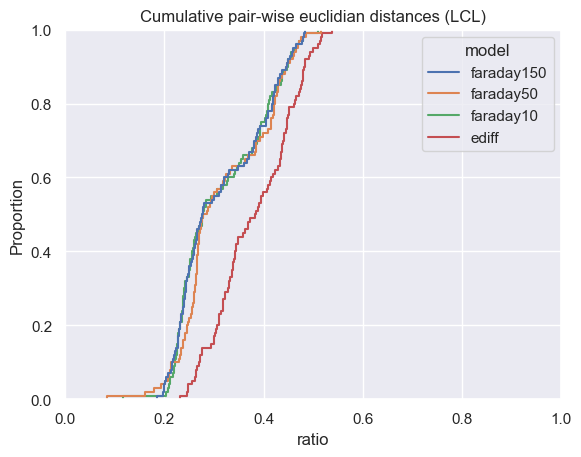

In [196]:
faraday150_lcl_distance_norm["model"] = "faraday150"
faraday50_lcl_distance_norm["model"] = "faraday50"
faraday10_lcl_distance_norm["model"] = "faraday10"
ediff_lcl_distance_norm["model"] = "ediff"

df_lcl_reconstruction_attack_results = pd.concat([
    faraday150_lcl_distance_norm,
    faraday50_lcl_distance_norm,
    faraday10_lcl_distance_norm,
    ediff_lcl_distance_norm,
]).reset_index(drop=True)

sns.ecdfplot( data=df_lcl_reconstruction_attack_results, x="ratio", hue="model").set_title("Cumulative pair-wise euclidian distances (LCL)")
plt.xlim(0, 1)

(0.0, 1.0)

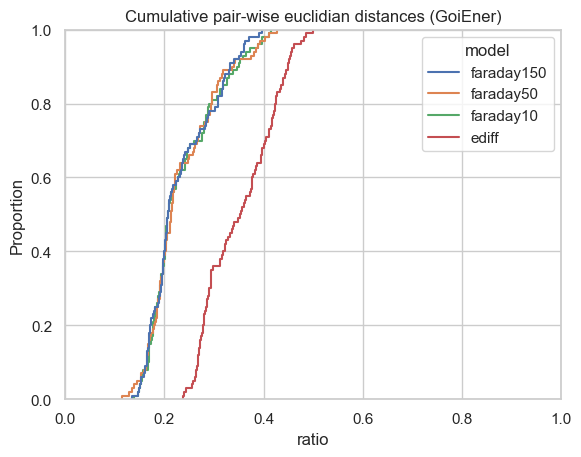

In [190]:
faraday150_goiener_distance_norm["model"] = "faraday150"
faraday50_goiener_distance_norm["model"] = "faraday50"
faraday10_goiener_distance_norm["model"] = "faraday10"
ediff_goiener_distance_norm["model"] = "ediff"

df_goiener_reconstruction_attack_results = pd.concat([
    faraday150_goiener_distance_norm,
    faraday50_goiener_distance_norm,
    faraday10_goiener_distance_norm,
    ediff_goiener_distance_norm,
]).reset_index(drop=True)

sns.ecdfplot(data=df_goiener_reconstruction_attack_results, x="ratio", hue="model").set_title("Cumulative pair-wise euclidian distances (GoiEner)")
plt.xlim(0, 1)

In [81]:
faraday150_lcl_distance_norm["dataset"] = "LCL"
faraday50_lcl_distance_norm["dataset"] = "LCL"
faraday10_lcl_distance_norm["dataset"] = "LCL"
ediff_lcl_distance_norm["dataset"] = "LCL"
faraday150_goiener_distance_norm["dataset"] = "GoiEner"
faraday50_goiener_distance_norm["dataset"] = "GoiEner"
faraday10_goiener_distance_norm["dataset"] = "GoiEner"
ediff_goiener_distance_norm["dataset"] = "GoiEner"

df_reconstruction_attack_results = pd.concat([
    faraday150_lcl_distance_norm,
    faraday50_lcl_distance_norm,
    faraday10_lcl_distance_norm,
    ediff_lcl_distance_norm,
    faraday150_goiener_distance_norm,
    faraday50_goiener_distance_norm,
    faraday10_goiener_distance_norm,
    ediff_goiener_distance_norm,
]).reset_index(drop=True)

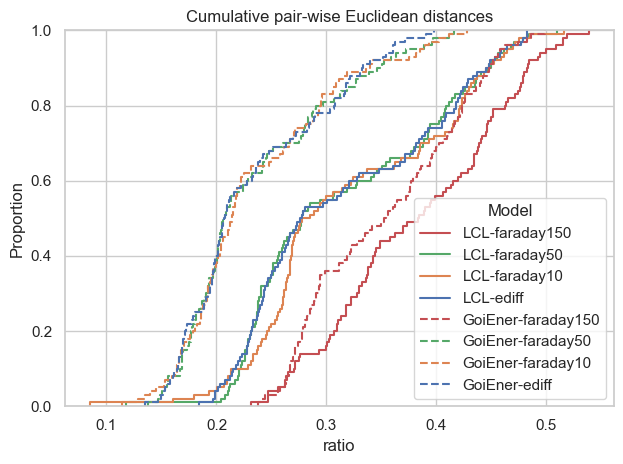

In [191]:
fig, ax = plt.subplots()

# 1) the first ECDF (solid lines by default)
sns.ecdfplot(
    data=df_reconstruction_attack_results.query("dataset=='LCL'"),
    x="ratio",
    hue="model",
    ax=ax,
    label="(solid)")

# 2) overlay a second plot—here we’ll re-plot ‘Ediff’ only, but dashed
sns.ecdfplot(
    data=df_reconstruction_attack_results.query("dataset == 'GoiEner'"),
    x="ratio",
    ax=ax,
    linestyle="--",   # Matplotlib linestyle
    hue="model"       # match your hue palette if needed
)

# 3) finish up
ax.set_title("Cumulative pair-wise Euclidean distances")
ax.set_xlabel("ratio")
ax.set_ylabel("Proportion")
ax.legend(["LCL-faraday150","LCL-faraday50","LCL-faraday10","LCL-ediff",
           "GoiEner-faraday150","GoiEner-faraday50","GoiEner-faraday10","GoiEner-ediff"], title="Model")
plt.tight_layout()
plt.savefig(f"figures/cum_euc.png", dpi=300, bbox_inches='tight')

plt.show()

# 5. Membership Inference Attacks


### 🏭 Create Membership Inference Attack Dataset

In [83]:
from opensynth.evaluation.privacy import membership_inference_attack as mia
import pytorch_lightning as pl

### LCL

In [84]:
dm_lcl_mia_faraday150 = mia.MembershipInferenceDataModule(
    model=faraday_lcl_models[150],
    dm_train=dm_lcl_with_outliers,
    dm_holdout=dm_lcl_holdout,
    batch_size=5000
)
dm_lcl_mia_faraday150.setup("")

dm_lcl_mia_faraday50 = mia.MembershipInferenceDataModule(
    model=faraday_lcl_models[50],
    dm_train=dm_lcl_with_outliers,
    dm_holdout=dm_lcl_holdout,
    batch_size=5000
)
dm_lcl_mia_faraday50.setup("")

dm_lcl_mia_faraday10 = mia.MembershipInferenceDataModule(
    model=faraday_lcl_models[10],
    dm_train=dm_lcl_with_outliers,
    dm_holdout=dm_lcl_holdout,
    batch_size=5000
)
dm_lcl_mia_faraday10.setup("")

In [85]:
dm_lcl_mia_ediff = mia.MembershipInferenceDataModule(
    model=df_lcl_model,
    dm_train=dm_lcl_with_outliers,
    dm_holdout=dm_lcl_holdout,
    batch_size=5000,
    synthetic_samples=df_lcl_kwh
)

dm_lcl_mia_ediff.setup("")

In [86]:
mia_lcl_model_faraday150 = mia.MembershipInferenceModel(learning_rate=0.02, input_size=48)
train_dl = dm_lcl_mia_faraday150.train_dataloader()
eval_dl = dm_lcl_mia_faraday150.eval_dataloader()
trainer = pl.Trainer(max_epochs=100, accelerator="auto", strategy="auto")
trainer.fit(mia_lcl_model_faraday150, train_dataloaders=train_dl, val_dataloaders=eval_dl)

mia_lcl_model_faraday50 = mia.MembershipInferenceModel(learning_rate=0.02, input_size=48)
train_dl = dm_lcl_mia_faraday50.train_dataloader()
eval_dl = dm_lcl_mia_faraday50.eval_dataloader()
trainer = pl.Trainer(max_epochs=100, accelerator="auto", strategy="auto")
trainer.fit(mia_lcl_model_faraday50, train_dataloaders=train_dl, val_dataloaders=eval_dl)

mia_lcl_model_faraday10 = mia.MembershipInferenceModel(learning_rate=0.02, input_size=48)
train_dl = dm_lcl_mia_faraday10.train_dataloader()
eval_dl = dm_lcl_mia_faraday10.eval_dataloader()
trainer = pl.Trainer(max_epochs=100, accelerator="auto", strategy="auto")
trainer.fit(mia_lcl_model_faraday10, train_dataloaders=train_dl, val_dataloaders=eval_dl)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name    | Type                      | Params | Mode 
--------------------------------------------------------------
0 | loss_fn | BCEWithLogitsLoss         | 0      

Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (5) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|██████████| 5/5 [00:00<00:00, 10.45it/s, v_num=22]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 5/5 [00:00<00:00, 43.08it/s, v_num=22, Eval BCE Loss=0.688, Eval Accuracy=0.548, Train BCE Loss=0.691, Train Accuracy=0.525]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 5/5 [00:00<00:00, 42.63it/s, v_num=22, Eval BCE Loss=0.685, Eval Accuracy=0.548, Train BCE Loss=0.689, Train Accuracy=0.539]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 5/5 [00:00<00:00, 21.72it/s, v_num=22, Eval BCE Loss=0.680, Eval Accuracy=0.534, Train BCE Loss=0.684, Train Accuracy=0.540]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 5/5 [00:00<00:00, 38.12it/s, v_num=22, Eval BCE Loss=0.671, Eval Accuracy=0.554, Train BCE Loss=0.676, Train Accuracy=0.560]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 5/5 [00:00<00:00, 41.88it/s, v_num=22, Eval BCE Loss=0.664, Eval Accuracy=0

...

Epoch 99: 100%|██████████| 5/5 [00:00<00:00, 32.61it/s, v_num=23, Eval BCE Loss=0.272, Eval Accuracy=0.899, Train BCE Loss=0.251, Train Accuracy=0.901]


Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type                      | Params | Mode 
--------------------------------------------------------------
0 | loss_fn | BCEWithLogitsLoss         | 0      | train
1 | model   | MembershipInferenceModule | 2.2 K  | train
--------------------------------------------------------------
2.2 K     Trainable params
0         Non-trainable params
2.2 K     Total params
0.009     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 5/5 [00:00<00:00, 38.36it/s, v_num=24]            
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 5/5 [00:00<00:00, 42.79it/s, v_num=24, Eval BCE Loss=0.691, Eval Accuracy=0.530, Train BCE Loss=0.692, Train Accuracy=0.519]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 5/5 [00:00<00:00, 43.90it/s, v_num=24, Eval BCE Loss=0.690, Eval Accuracy=0.534, Train BCE Loss=0.688, Train Accuracy=0.543]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 5/5 [00:00<00:00, 43.92it/s, v_num=24, Eval BCE Loss=0.684, Eval Accuracy=0.535, Train BCE Loss=0.685, Train Accuracy=0.543]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 5/5 [00:00<00:00, 42.69it/s, v_num=24, Eval BCE Loss=0.676, Eval Accuracy=0.533, Train BCE Loss=0.679, Train Accuracy=0.552]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 5/5 [00:00<00:00, 17.11it/s, v_num=24, Eval BCE Loss=0.664, Eva

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 5/5 [00:00<00:00, 32.33it/s, v_num=24, Eval BCE Loss=0.268, Eval Accuracy=0.913, Train BCE Loss=0.216, Train Accuracy=0.916]


In [87]:
mia_lcl_model_ediff = mia.MembershipInferenceModel(learning_rate=0.02,
                                            input_size=48)
train_dl = dm_lcl_mia_ediff.train_dataloader()
eval_dl = dm_lcl_mia_ediff.eval_dataloader()
trainer = pl.Trainer(max_epochs=100, accelerator="auto", strategy="auto")
trainer.fit(mia_lcl_model_ediff,
            train_dataloaders=train_dl,
            val_dataloaders=eval_dl)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type                      | Params | Mode 
--------------------------------------------------------------
0 | loss_fn | BCEWithLogitsLoss         | 0      | train
1 | model   | MembershipInferenceModule | 2.2 K  | train
--------------------------------------------------------------
2.2 K     Trainable params
0         Non-trainable params
2.2 K     Total params
0.009     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (6) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|██████████| 6/6 [00:00<00:00, 40.32it/s, v_num=25]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 6/6 [00:00<00:00, 44.09it/s, v_num=25, Eval BCE Loss=0.692, Eval Accuracy=0.531, Train BCE Loss=0.696, Train Accuracy=0.508]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 6/6 [00:00<00:00, 42.97it/s, v_num=25, Eval BCE Loss=0.691, Eval Accuracy=0.502, Train BCE Loss=0.691, Train Accuracy=0.509]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 6/6 [00:00<00:00, 13.74it/s, v_num=25, Eval BCE Loss=0.689, Eval Accuracy=0.537, Train BCE Loss=0.690, Train Accuracy=0.518]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 6/6 [00:00<00:00, 36.52it/s, v_num=25, Eval BCE Loss=0.688, Eval Accuracy=0.530, Train BCE Loss=0.687, Train Accuracy=0.528]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 6/6 [00:00<00:00, 29.49it/s, v_num=25, Eval BCE Loss=0.686, Eval Accuracy=0

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 6/6 [00:00<00:00, 33.98it/s, v_num=25, Eval BCE Loss=0.708, Eval Accuracy=0.544, Train BCE Loss=0.658, Train Accuracy=0.580]


#### GoiEner

In [88]:
dm_goiener_mia_faraday150 = mia.MembershipInferenceDataModule(
    model=faraday_goiener_models[150],
    dm_train=dm_goiener_with_outliers,
    dm_holdout=dm_goiener_holdout,
    batch_size=5000
)
dm_goiener_mia_faraday150.setup("")

dm_goiener_mia_faraday50 = mia.MembershipInferenceDataModule(
    model=faraday_goiener_models[50],
    dm_train=dm_goiener_with_outliers,
    dm_holdout=dm_goiener_holdout,
    batch_size=5000
)
dm_goiener_mia_faraday50.setup("")

dm_goiener_mia_faraday10 = mia.MembershipInferenceDataModule(
    model=faraday_goiener_models[10],
    dm_train=dm_goiener_with_outliers,
    dm_holdout=dm_goiener_holdout,
    batch_size=5000
)
dm_goiener_mia_faraday10.setup("")

dm_goiener_mia_ediff = mia.MembershipInferenceDataModule(
    model=df_goiener_model,
    dm_train=dm_goiener_with_outliers,
    dm_holdout=dm_goiener_holdout,
    batch_size=5000,
    synthetic_samples=df_goiener_kwh
)
dm_goiener_mia_ediff.setup("")

In [89]:
mia_goiener_model_faraday150 = mia.MembershipInferenceModel(learning_rate=0.02, input_size=48)
train_dl = dm_goiener_mia_faraday150.train_dataloader()
eval_dl = dm_goiener_mia_faraday150.eval_dataloader()
trainer = pl.Trainer(max_epochs=100, accelerator="auto", strategy="auto")
trainer.fit(mia_goiener_model_faraday150, train_dataloaders=train_dl, val_dataloaders=eval_dl)

mia_goiener_model_faraday50 = mia.MembershipInferenceModel(learning_rate=0.02, input_size=48)
train_dl = dm_goiener_mia_faraday50.train_dataloader()
eval_dl = dm_goiener_mia_faraday50.eval_dataloader()
trainer = pl.Trainer(max_epochs=100, accelerator="auto", strategy="auto")
trainer.fit(mia_goiener_model_faraday50, train_dataloaders=train_dl, val_dataloaders=eval_dl)

mia_goiener_model_faraday10 = mia.MembershipInferenceModel(learning_rate=0.02, input_size=48)
train_dl = dm_goiener_mia_faraday10.train_dataloader()
eval_dl = dm_goiener_mia_faraday10.eval_dataloader()
trainer = pl.Trainer(max_epochs=100, accelerator="auto", strategy="auto")
trainer.fit(mia_goiener_model_faraday10, train_dataloaders=train_dl, val_dataloaders=eval_dl)

mia_goiener_model_ediff = mia.MembershipInferenceModel(learning_rate=0.02, input_size=48)
train_dl = dm_goiener_mia_ediff.train_dataloader()
eval_dl = dm_goiener_mia_ediff.eval_dataloader()
trainer = pl.Trainer(max_epochs=100, accelerator="auto", strategy="auto")
trainer.fit(mia_goiener_model_ediff, train_dataloaders=train_dl, val_dataloaders=eval_dl)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type                      | Params | Mode 
--------------------------------------------------------------
0 | loss_fn | BCEWithLogitsLoss         | 0      | train
1 | model   | MembershipInferenceModule | 2.2 K  | train
--------------------------------------------------------------
2.2 K     Trainable params
0         Non-trainable params
2.2 K     Total params
0.009     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (5) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|██████████| 5/5 [00:00<00:00, 36.80it/s, v_num=26]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 5/5 [00:00<00:00, 42.80it/s, v_num=26, Eval BCE Loss=0.684, Eval Accuracy=0.554, Train BCE Loss=0.688, Train Accuracy=0.545]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 5/5 [00:00<00:00, 43.54it/s, v_num=26, Eval BCE Loss=0.682, Eval Accuracy=0.548, Train BCE Loss=0.685, Train Accuracy=0.549]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 5/5 [00:00<00:00, 42.57it/s, v_num=26, Eval BCE Loss=0.680, Eval Accuracy=0.561, Train BCE Loss=0.682, Train Accuracy=0.551]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 5/5 [00:00<00:00, 43.19it/s, v_num=26, Eval BCE Loss=0.677, Eval Accuracy=0.564, Train BCE Loss=0.680, Train Accuracy=0.549]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 5/5 [00:00<00:00, 43.62it/s, v_num=26, Eval BCE Loss=0.676, Eval Accuracy=0

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 5/5 [00:00<00:00, 32.17it/s, v_num=26, Eval BCE Loss=0.422, Eval Accuracy=0.808, Train BCE Loss=0.402, Train Accuracy=0.806]


...

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type                      | Params | Mode 
--------------------------------------------------------------
0 | loss_fn | BCEWithLogitsLoss         | 0      | train
1 | model   | MembershipInferenceModule | 2.2 K  | train
--------------------------------------------------------------
2.2 K     Trainable params
0         Non-trainable params
2.2 K     Total params
0.009     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (6) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|██████████| 6/6 [00:00<00:00, 32.37it/s, v_num=29]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 6/6 [00:00<00:00, 42.44it/s, v_num=29, Eval BCE Loss=0.692, Eval Accuracy=0.505, Train BCE Loss=0.694, Train Accuracy=0.507]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 6/6 [00:00<00:00, 44.14it/s, v_num=29, Eval BCE Loss=0.693, Eval Accuracy=0.504, Train BCE Loss=0.693, Train Accuracy=0.508]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 6/6 [00:00<00:00, 41.79it/s, v_num=29, Eval BCE Loss=0.692, Eval Accuracy=0.516, Train BCE Loss=0.692, Train Accuracy=0.515]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 6/6 [00:00<00:00, 42.33it/s, v_num=29, Eval BCE Loss=0.691, Eval Accuracy=0.516, Train BCE Loss=0.692, Train Accuracy=0.517]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 6/6 [00:00<00:00, 43.77it/s, v_num=29, Eval BCE Loss=0.690, Eval Accuracy=0

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 6/6 [00:00<00:00, 30.25it/s, v_num=29, Eval BCE Loss=0.689, Eval Accuracy=0.503, Train BCE Loss=0.644, Train Accuracy=0.565]


## Check precision

Results show that Faraday trained with 1500 and 150 GMM Clusters failed membership inference attacks, whilst 50 GMM Clusters and 1 GMM cluster passed. However we also see that 50 GMM cluster failed the reconstruction attack, hence it is not safe for release.


### LCL

In [90]:
df_lcl_mia_results_faraday150 = mia.get_mia_predictions(mia_lcl_model_faraday150, dm_lcl_mia_faraday150)
mia.print_mia_results(df_lcl_mia_results_faraday150)

Segment: Precision: 0.29 +/- 0.05,
F1: 0.29, Acc: 0.53,
True Positives: 29,
False Positive: 71,
Total N: 300,
Total Positive: 100,
Random Precision : 0.33,


In [91]:
df_lcl_mia_results_faraday50 = mia.get_mia_predictions(mia_lcl_model_faraday50, dm_lcl_mia_faraday50)
mia.print_mia_results(df_lcl_mia_results_faraday50)

Segment: Precision: 0.42 +/- 0.06,
F1: 0.42, Acc: 0.61,
True Positives: 42,
False Positive: 58,
Total N: 300,
Total Positive: 100,
Random Precision : 0.33,


In [92]:
df_lcl_mia_results_faraday10 = mia.get_mia_predictions(mia_lcl_model_faraday10, dm_lcl_mia_faraday10)
mia.print_mia_results(df_lcl_mia_results_faraday10)

Segment: Precision: 0.24 +/- 0.05,
F1: 0.24, Acc: 0.49,
True Positives: 24,
False Positive: 76,
Total N: 300,
Total Positive: 100,
Random Precision : 0.33,


In [93]:
df_lcl_mia_results_ediff = mia.get_mia_predictions(mia_lcl_model_ediff, dm_lcl_mia_ediff)
mia.print_mia_results(df_lcl_mia_results_ediff)

Segment: Precision: 0.30 +/- 0.05,
F1: 0.30, Acc: 0.53,
True Positives: 30,
False Positive: 70,
Total N: 300,
Total Positive: 100,
Random Precision : 0.33,


### GoiEner

In [94]:
df_goiener_mia_results_faraday150 = mia.get_mia_predictions(mia_goiener_model_faraday150, dm_goiener_mia_faraday150)
mia.print_mia_results(df_goiener_mia_results_faraday150)

Segment: Precision: 0.39 +/- 0.06,
F1: 0.39, Acc: 0.59,
True Positives: 39,
False Positive: 61,
Total N: 300,
Total Positive: 100,
Random Precision : 0.33,


In [95]:
df_goiener_mia_results_faraday50 = mia.get_mia_predictions(mia_goiener_model_faraday50, dm_goiener_mia_faraday50)
mia.print_mia_results(df_goiener_mia_results_faraday50)

Segment: Precision: 0.41 +/- 0.06,
F1: 0.41, Acc: 0.61,
True Positives: 41,
False Positive: 59,
Total N: 300,
Total Positive: 100,
Random Precision : 0.33,


In [96]:
df_goiener_mia_results_faraday10 = mia.get_mia_predictions(mia_goiener_model_faraday10, dm_goiener_mia_faraday10)
mia.print_mia_results(df_goiener_mia_results_faraday10)

Segment: Precision: 0.53 +/- 0.06,
F1: 0.53, Acc: 0.69,
True Positives: 53,
False Positive: 47,
Total N: 300,
Total Positive: 100,
Random Precision : 0.33,


In [97]:
df_goiener_mia_results_ediff = mia.get_mia_predictions(mia_goiener_model_ediff, dm_goiener_mia_ediff)
mia.print_mia_results(df_goiener_mia_results_ediff)

Segment: Precision: 0.25 +/- 0.05,
F1: 0.25, Acc: 0.50,
True Positives: 25,
False Positive: 75,
Total N: 300,
Total Positive: 100,
Random Precision : 0.33,


In [171]:
print("LCL")
print("faraday_150")
mia.print_mia_results(df_lcl_mia_results_faraday150)
print("faraday_50")
mia.print_mia_results(df_lcl_mia_results_faraday50)
print("faraday_10")
mia.print_mia_results(df_lcl_mia_results_faraday10)
print("energy_diff")
mia.print_mia_results(df_lcl_mia_results_ediff)

print("\nGoiEner")
print("faraday_150")
mia.print_mia_results(df_goiener_mia_results_faraday150)
print("faraday_50")
mia.print_mia_results(df_goiener_mia_results_faraday50)
print("faraday_10")
mia.print_mia_results(df_goiener_mia_results_faraday10)
print("energy_diff")
mia.print_mia_results(df_goiener_mia_results_ediff)


LCL
faraday_150
Segment: Precision: 0.29 +/- 0.05,
F1: 0.29, Acc: 0.53,
True Positives: 29,
False Positive: 71,
Total N: 300,
Total Positive: 100,
Random Precision : 0.33,
faraday_50
Segment: Precision: 0.42 +/- 0.06,
F1: 0.42, Acc: 0.61,
True Positives: 42,
False Positive: 58,
Total N: 300,
Total Positive: 100,
Random Precision : 0.33,
faraday_10
Segment: Precision: 0.24 +/- 0.05,
F1: 0.24, Acc: 0.49,
True Positives: 24,
False Positive: 76,
Total N: 300,
Total Positive: 100,
Random Precision : 0.33,
energy_diff
Segment: Precision: 0.30 +/- 0.05,
F1: 0.30, Acc: 0.53,
True Positives: 30,
False Positive: 70,
Total N: 300,
Total Positive: 100,
Random Precision : 0.33,

GoiEner
faraday_150
Segment: Precision: 0.39 +/- 0.06,
F1: 0.39, Acc: 0.59,
True Positives: 39,
False Positive: 61,
Total N: 300,
Total Positive: 100,
Random Precision : 0.33,
faraday_50
Segment: Precision: 0.41 +/- 0.06,
F1: 0.41, Acc: 0.61,
True Positives: 41,
False Positive: 59,
Total N: 300,
Total Positive: 100,
Random 

# 6. Temporal Fidelity

In [14]:
from opensynth.evaluation.fidelity.generate_data import load_lcl_data_by_year, generate_full_synthetic_year, load_goiener_data_by_year
YEAR_LCL = 2013
YEAR_GOIENER = 2018

In [ ]:
lcl_fid = load_lcl_data_by_year(fname=LCL_RAW_DATA_PATH / "train.csv", year=YEAR_LCL)

In [13]:
goiener_fid = load_goiener_data_by_year(fname=GOIENER_RAW_DATA_PATH / "train.csv", year=YEAR_GOIENER)

### Generate samples

In [14]:
from opensynth.evaluation.fidelity.generate_ediff_data import generate_synthetic_samples
import polars as pls

### LCL

In [ ]:
faraday_lcl_150_yearly = generate_full_synthetic_year(faraday_lcl_models[150], dm_lcl, year=YEAR_LCL, n_samples=3000)
faraday_lcl_150_yearly.to_csv('faraday_lcl_150_yearly.csv')

In [14]:
faraday_lcl_50_yearly = generate_full_synthetic_year(faraday_lcl_models[50], dm_lcl, year=YEAR_LCL, n_samples=3000)
faraday_lcl_50_yearly.to_csv('faraday_lcl_50_yearly.csv')

100%|██████████| 12/12 [41:02<00:00, 205.23s/it] 


In [15]:
faraday_lcl_10_yearly = generate_full_synthetic_year(faraday_lcl_models[10], dm_lcl, year=YEAR_LCL, n_samples=3000)
faraday_lcl_10_yearly.to_csv('faraday_lcl_10_yearly.csv')


100%|██████████| 12/12 [38:41<00:00, 193.47s/it] 


In [15]:
faraday_lcl_150_yearly = pls.read_csv('faraday_lcl_150_yearly.csv', try_parse_dates=True)
faraday_lcl_50_yearly = pls.read_csv('faraday_lcl_50_yearly.csv', try_parse_dates=True)
faraday_lcl_10_yearly = pls.read_csv('faraday_lcl_10_yearly.csv', try_parse_dates=True)

In [16]:
faraday_goiener_150_yearly = pls.read_csv('faraday_goiener_150.csv', try_parse_dates=True)
faraday_goiener_50_yearly = pls.read_csv('faraday_goiener_50.csv', try_parse_dates=True)
faraday_goiener_10_yearly = pls.read_csv('faraday_goiener_10.csv', try_parse_dates=True)

ediff_lcl_yearly = pls.read_csv('ediff_lcl_yearly.csv', try_parse_dates=True)

ediff_goiener_yearly = pls.read_csv('ediff_goiener_yearly.csv', try_parse_dates=True)

In [21]:
ediff_lcl_yearly = generate_synthetic_samples(
    df_lcl_model,
    dm_lcl,
    n_profiles=1,   # ← 100 synthetic profiles
    year=YEAR_LCL,        # or whichever year you like
    month=None,       # ← ensure full 365 days
    batch_size=100,   # adjust to taste (GPU/memory)
    step=100,
)

sampling batch 1/4,                     batch size 100. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:07<00:00, 12.66it/s]


sampling batch 2/4,                     batch size 100. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:07<00:00, 12.68it/s]


sampling batch 3/4,                     batch size 100. 


multistep_dpm_solver_update:  41%|████      | 40/98 [00:03<00:04, 12.33it/s]


KeyboardInterrupt: 

In [23]:
ediff_lcl_yearly = generate_synthetic_samples(
    df_lcl_model,
    dm_lcl,
    n_profiles=1000,   # ← 100 synthetic profiles
    year=YEAR_LCL,        # or whichever year you like
    month=None,       # ← ensure full 365 days
    batch_size=1000,   # adjust to taste (GPU/memory)
    step=100,
)

sampling batch 1/365,                     batch size 1000. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:56<00:00,  1.74it/s]


sampling batch 2/365,                     batch size 1000. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:54<00:00,  1.79it/s]


sampling batch 3/365,                     batch size 1000. 


...

sampling batch 18/365,                     batch size 1000. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:58<00:00,  1.68it/s]


sampling batch 19/365,                     batch size 1000. 


multistep_dpm_solver_update:  59%|█████▉    | 58/98 [00:35<00:24,  1.65it/s]


KeyboardInterrupt: 

In [17]:
benchmark_lcl_set = {
    "Real data": lcl_fid,
    "faraday_150": faraday_lcl_150_yearly,
    "faraday_50": faraday_lcl_50_yearly,
    "faraday_10": faraday_lcl_10_yearly,
    "energy_diff": ediff_lcl_yearly
}

### GoiEner

In [16]:
faraday_goiener_150 = generate_full_synthetic_year(faraday_goiener_models[150], dm_goiener, year=YEAR_GOIENER, n_samples=3000)
faraday_goiener_150.to_csv('faraday_goiener_150.csv')

100%|██████████| 12/12 [32:34<00:00, 162.91s/it] 


In [17]:
faraday_goiener_50 = generate_full_synthetic_year(faraday_goiener_models[50], dm_goiener, year=YEAR_GOIENER, n_samples=3000)
faraday_goiener_50.to_csv('faraday_goiener_50.csv')

100%|██████████| 12/12 [35:23<00:00, 176.93s/it] 


In [18]:
faraday_goiener_10 = generate_full_synthetic_year(faraday_goiener_models[10], dm_goiener, year=YEAR_GOIENER, n_samples=3000)
faraday_goiener_10.to_csv('faraday_goiener_10.csv')

100%|██████████| 12/12 [33:31<00:00, 167.61s/it] 


In [22]:
ediff_goiener_yearly = generate_synthetic_samples(
    df_goiener_model,
    dm_goiener,
    n_profiles=100,   # ← 100 synthetic profiles
    year=YEAR_GOIENER,        # or whichever year you like
    month=None,       # ← ensure full 365 days
    batch_size=1000,   # adjust to taste (GPU/memory)
    step=100,
)

sampling batch 1/37,                     batch size 1000. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:55<00:00,  1.78it/s]


sampling batch 2/37,                     batch size 1000. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:55<00:00,  1.78it/s]


sampling batch 3/37,                     batch size 1000. 


...

multistep_dpm_solver_update: 100%|██████████| 98/98 [00:53<00:00,  1.83it/s]


sampling batch 36/37,                     batch size 1000. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:53<00:00,  1.83it/s]


sampling batch 37/37,                     batch size 500. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:23<00:00,  4.13it/s]


In [21]:
import seaborn as sns

In [19]:
benchmark_goiener_set = {
    "Real data": goiener_fid,
    "faraday_150": faraday_goiener_150_yearly,
    "faraday_50": faraday_goiener_50_yearly,
    "faraday_10": faraday_goiener_10_yearly,
    "energy_diff": ediff_goiener_yearly
}

In [22]:
sns.set_theme(style="whitegrid")

### Results

In [23]:
from opensynth.evaluation.fidelity.seasonal_statistics import calculate_seasonal_peaks, plot_seasonal_stats, pairwise_seasonal_kstest

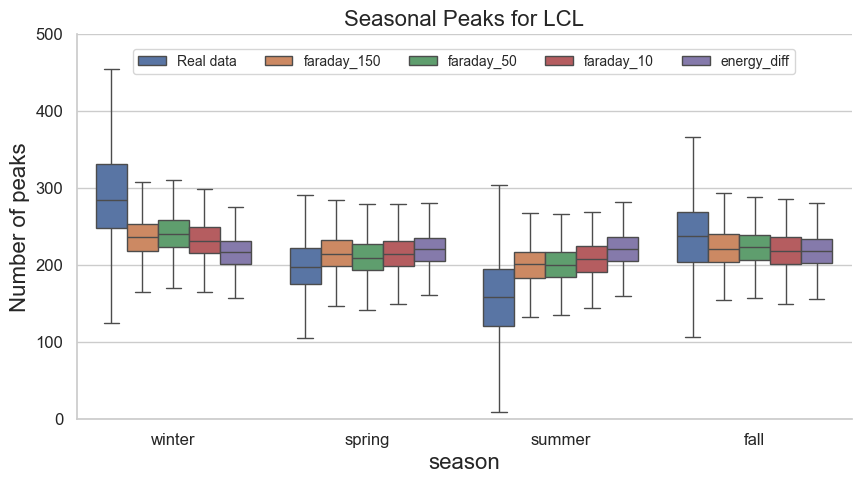

In [24]:
# LCL
result_lcl = calculate_seasonal_peaks(benchmark_lcl_set, high_low="high", )
plot_seasonal_stats(result_lcl, "LCL")

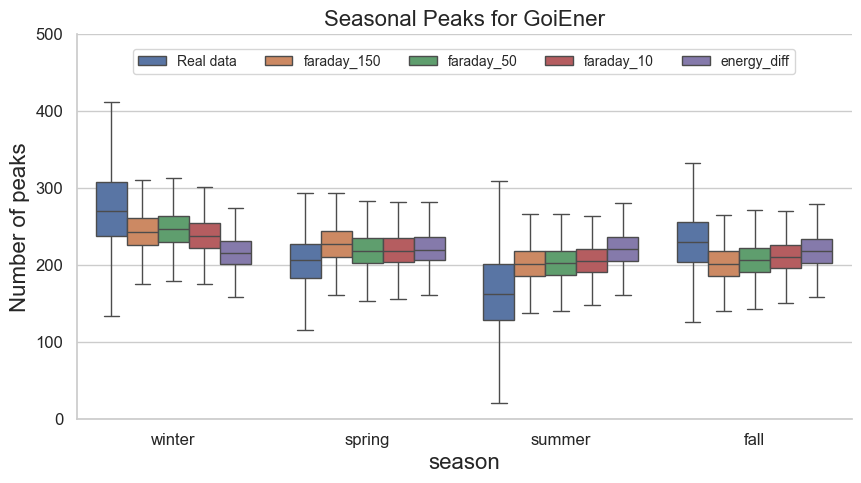

In [25]:
# GoiEner
result_goiener = calculate_seasonal_peaks(benchmark_goiener_set, high_low="high", )
plot_seasonal_stats(result_goiener, 'GoiEner')

### Autocorrelation

In [8]:
from opensynth.evaluation.fidelity.autocorrelation import  calculate_auto_correlation, plot_autocorrelation_stats

In [27]:
# LCL
result_lcl_ac = calculate_auto_correlation(benchmark_lcl_set)

/Users/hajalibayram/phd/dev/OpenSynth/src/opensynth/evaluation/fidelity/autocorrelation.py:64: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  result[time_delta] = pearsonr(


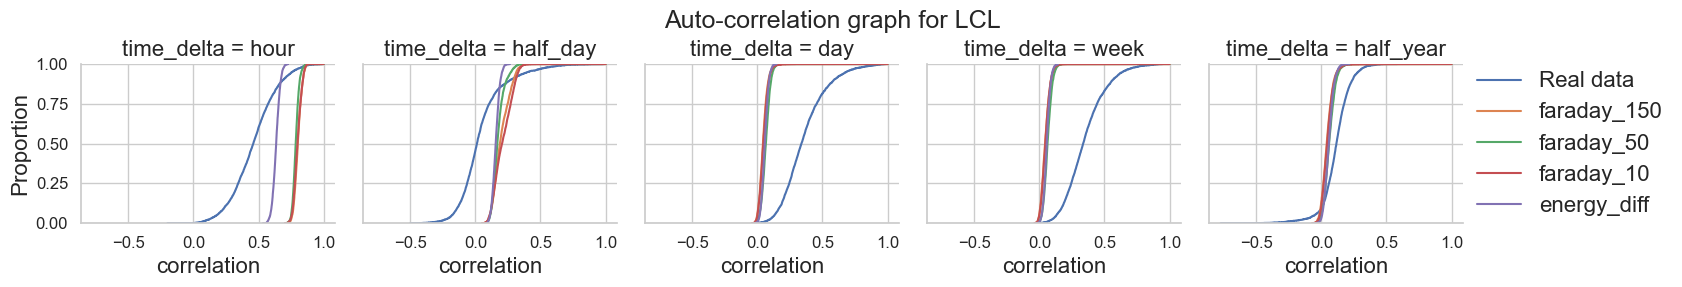

In [28]:
plot_autocorrelation_stats(result_lcl_ac, "LCL")

/Users/hajalibayram/phd/dev/OpenSynth/src/opensynth/evaluation/fidelity/autocorrelation.py:64: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  result[time_delta] = pearsonr(


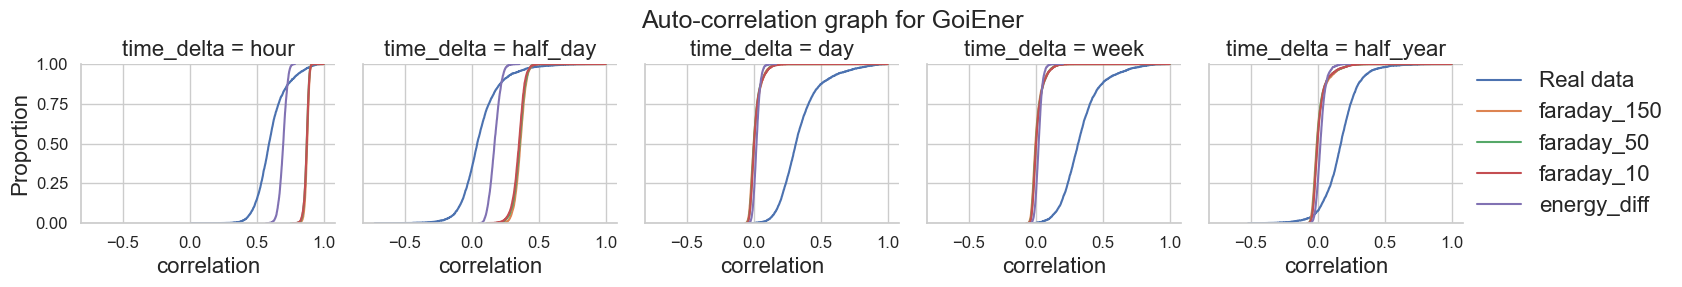

In [29]:
# GoiEner
result_goiener_ac = calculate_auto_correlation(benchmark_goiener_set)
plot_autocorrelation_stats(result_goiener_ac, "GoiEner")

In [14]:
import torch
import polars as pls

In [20]:
ediff_cal = torch.load('ediff_1_cal.pt')
d = pls.DataFrame(ediff_cal.cpu().detach().numpy())

In [27]:
type(d)

polars.dataframe.frame.DataFrame

In [21]:
ediff_cal

tensor([[0.3060, 0.3980, 0.4380,  ..., 0.3890, 0.3640, 0.2720],
        [0.0120, 0.0460, 0.0290,  ..., 0.3330, 0.1360, 0.0450],
        [0.3330, 0.3030, 0.1020,  ..., 0.1150, 0.1030, 0.0930],
        ...,
        [0.0610, 0.0440, 0.0060,  ..., 0.2060, 0.1880, 0.1760],
        [0.1050, 0.1160, 0.1280,  ..., 0.9650, 0.7260, 0.0480],
        [0.1410, 0.1510, 0.1310,  ..., 0.7960, 0.7880, 1.0020]],
       device='mps:0')

In [32]:
import polars as pl
import datetime as dt

# 1) Flatten to 17520 x 1
values = d.select(pl.concat_list(pl.all()).alias("value")).explode("value")

# 2) Build 30-minute timestamps
n = values.height
start = dt.datetime(2013, 1, 1)
end = start + dt.timedelta(minutes=30 * (n - 1))

ts = pl.datetime_range(start=start, end=end, interval="30m", eager=True)  # no 'name='
ts = ts.rename("datetime")

# 3) Combine
out = pl.DataFrame({"datetime": ts}).hstack(values)

# (optional) make timezone-aware, e.g. UTC:
# out = out.with_columns(pl.col("datetime").dt.replace_time_zone("UTC"))


In [33]:
out

datetime,value
datetime[μs],f32
2013-01-01 00:00:00,0.306
2013-01-01 00:30:00,0.398
2013-01-01 01:00:00,0.438
2013-01-01 01:30:00,0.348
2013-01-01 02:00:00,0.313
…,…
2013-12-31 21:30:00,0.677
2013-12-31 22:00:00,0.839
2013-12-31 22:30:00,0.796


In [22]:
ediff_lcl_yearly = pls.read_csv('ediff_lcl_yearly.csv', try_parse_dates=True)

In [23]:
ediff_lcl_yearly

datetime,profile_0,profile_1,profile_2,profile_3,profile_4,profile_5,profile_6,profile_7,profile_8,profile_9,profile_10,profile_11,profile_12,profile_13,profile_14,profile_15,profile_16,profile_17,profile_18,profile_19,profile_20,profile_21,profile_22,profile_23,profile_24,profile_25,profile_26,profile_27,profile_28,profile_29,profile_30,profile_31,profile_32,profile_33,profile_34,profile_35,…,profile_2963,profile_2964,profile_2965,profile_2966,profile_2967,profile_2968,profile_2969,profile_2970,profile_2971,profile_2972,profile_2973,profile_2974,profile_2975,profile_2976,profile_2977,profile_2978,profile_2979,profile_2980,profile_2981,profile_2982,profile_2983,profile_2984,profile_2985,profile_2986,profile_2987,profile_2988,profile_2989,profile_2990,profile_2991,profile_2992,profile_2993,profile_2994,profile_2995,profile_2996,profile_2997,profile_2998,profile_2999
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2013-01-01 00:00:00,0.202,0.037,0.181,0.244,0.093,0.317,0.073,0.07,0.081,0.017,0.077,0.186,0.063,0.206,0.054,0.017,0.741,0.079,0.105,0.061,0.081,0.061,0.129,0.279,0.084,0.048,0.052,0.05,0.121,0.034,0.103,0.074,0.017,0.104,0.073,0.073,…,0.203,0.017,0.129,0.017,0.042,0.042,0.02,0.176,0.435,0.067,0.096,0.488,0.291,0.197,0.569,0.045,0.093,0.145,0.711,0.126,0.161,0.176,0.172,0.086,0.199,0.219,0.048,0.059,0.04,0.172,0.059,0.21,0.161,0.104,0.435,0.569,0.333
2013-01-01 00:30:00,0.124,0.03,0.112,0.226,0.082,0.059,0.032,0.195,0.067,0.011,0.032,0.132,0.042,0.036,0.034,0.011,0.531,0.023,0.093,0.226,0.035,0.043,0.106,0.311,0.155,0.053,0.053,0.041,0.094,0.011,0.067,0.034,0.026,0.072,0.041,0.085,…,0.155,0.011,0.112,0.011,0.042,0.04,0.011,0.073,0.352,0.077,0.063,0.329,0.172,0.134,0.531,0.042,0.053,0.085,0.276,0.109,0.106,0.137,0.143,0.058,0.172,0.037,0.039,0.043,0.053,0.172,0.073,0.133,0.134,0.119,0.827,0.274,0.274
2013-01-01 01:00:00,0.294,0.032,0.112,0.207,0.075,0.039,0.046,0.105,0.065,0.02,0.081,0.136,0.044,0.061,0.043,0.013,0.465,0.05,0.098,0.025,0.026,0.074,0.11,0.689,0.073,0.074,0.057,0.046,0.09,0.018,0.038,0.029,0.018,0.058,0.042,0.064,…,0.142,0.012,0.105,0.025,0.041,0.017,0.018,0.084,0.266,0.093,0.052,0.313,0.071,0.207,0.549,0.057,0.059,0.061,0.215,0.091,0.129,0.136,0.131,0.061,0.129,0.038,0.025,0.057,0.035,0.143,0.034,0.135,0.098,0.128,0.173,0.039,0.212
2013-01-01 01:30:00,0.08,0.021,0.145,0.184,0.071,0.103,0.063,0.112,0.054,0.012,0.048,0.13,0.029,0.022,0.028,0.012,0.323,0.037,0.091,0.028,0.035,0.073,0.083,0.75,0.035,0.04,0.04,0.035,0.079,0.017,0.051,0.037,0.012,0.073,0.048,0.065,…,0.116,0.012,0.116,0.012,0.022,0.048,0.015,0.052,0.147,0.063,0.078,0.355,0.05,0.045,0.433,0.047,0.067,0.042,0.348,0.089,0.156,0.017,0.142,0.037,0.135,0.079,0.037,0.044,0.036,0.254,0.037,0.13,0.12,0.109,0.433,0.052,0.29
2013-01-01 02:00:00,0.065,0.025,0.17,0.183,0.056,0.036,0.048,0.084,0.04,0.011,0.036,0.129,0.047,0.025,0.031,0.011,0.32,0.033,0.063,0.033,0.034,0.125,0.095,0.429,0.037,0.025,0.065,0.042,0.118,0.046,0.042,0.038,0.015,0.048,0.06,0.054,…,0.099,0.011,0.142,0.035,0.043,0.032,0.011,0.038,0.066,0.062,0.085,0.313,0.06,0.088,0.381,0.045,0.048,0.222,0.29,0.129,0.143,0.095,0.151,0.037,0.066,0.071,0.046,0.035,0.07,0.171,0.108,0.16,0.196,0.099,0.13,0.29,0.18
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013-12-31 21:30:00,0.041,0.571,0.037,0.047,0.037,0.166,0.166,1.029,0.055,0.898,0.07,1.273,0.204,0.044,0.294,0.204,0.093,1.029,0.284,0.156,0.0,0.532,0.483,1.164,0.109,0.684,0.212,0.684,0.409,0.451,0.16,0.216,0.684,0.07,0.12,0.246,…,0.074,0.182,0.054,0.147,0.299,0.093,0.263,0.182,0.083,0.12,0.42,0.187,0.045,0.088,0.12,0.451,0.294,0.101,0.532,0.451,0.476,0.227,0.212,0.132,0.352,0.483,0.488,0.109

In [34]:
result_test_ac = calculate_auto_correlation({"test":out})

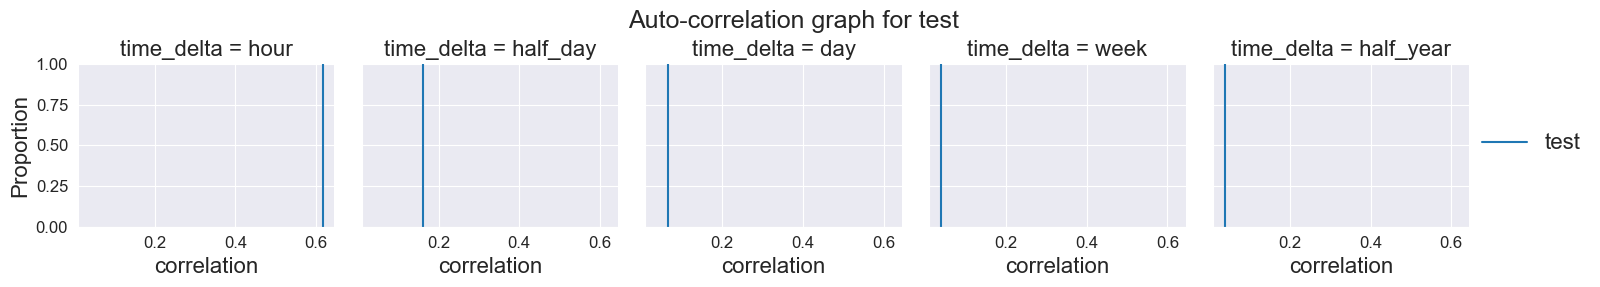

In [35]:
plot_autocorrelation_stats(result_test_ac, "test")